In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("ETA training environment ready")

ETA training environment ready


In [2]:
task_df = pd.read_csv("../../data/synthetic_task_data.csv")

print("Shape:", task_df.shape)
task_df.head()

features = [
    "Task Type",
    "Weather",
    "Operator Skill",
    "Machine Age (yrs)",
    "Estimated Time (min)"
]

target = "Actual Time (min)"

X = task_df[features].copy()
y = task_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

categorical_features = [
    "Task Type",
    "Weather",
    "Operator Skill"
]

numerical_features = [
    "Machine Age (yrs)",
    "Estimated Time (min)"
]
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features),
        ("numerical", numerical_transformer, numerical_features)
    ]
)

linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

pd.DataFrame(results)

Shape: (500, 7)
X shape: (500, 5)
y shape: (500,)
Training: (400, 5)
Testing: (100, 5)


,Model,MAE,RMSE,R2
0,Linear Regression,4.208749,5.560442,0.947465


In [3]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,4.208749,5.560442,0.947465
1,Random Forest,4.552525,5.781503,0.943205


In [4]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict(X_test)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,4.208749,5.560442,0.947465
1,Random Forest,4.552525,5.781503,0.943205
2,Gradient Boosting,4.553082,5.696380,0.944865


In [5]:
hist_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

hist_pipeline.fit(X_train, y_train)

hist_pred = hist_pipeline.predict(X_test)

results.append(
    evaluate_model(
        "Hist Gradient Boosting",
        y_test,
        hist_pred
    )
)

results_df = pd.DataFrame(results)

results_df

results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

,Model,MAE,RMSE,R2
0,Linear Regression,4.208749,5.560442,0.947465
1,Hist Gradient Boosting,4.548707,5.826016,0.942327
2,Random Forest,4.552525,5.781503,0.943205
3,Gradient Boosting,4.553082,5.696380,0.944865


CV MAE: 4.834058998015873 +/- 0.38795255139776624
CV RMSE: 6.110333344270401 +/- 0.5142980324062267
CV R2: 0.9270784432965279 +/- 0.018072935999694707


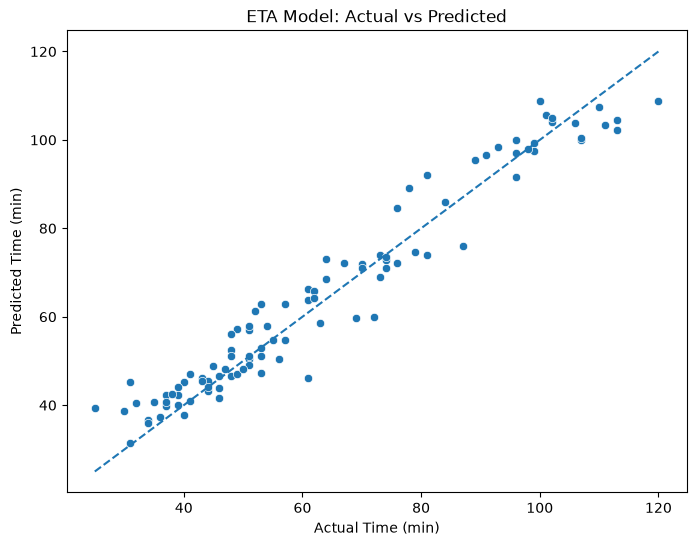

ETA model saved


In [6]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

print(
    "CV MAE:",
    -cv_scores["test_mae"].mean(),
    "+/-",
    cv_scores["test_mae"].std()
)

print(
    "CV RMSE:",
    -cv_scores["test_rmse"].mean(),
    "+/-",
    cv_scores["test_rmse"].std()
)

print(
    "CV R2:",
    cv_scores["test_r2"].mean(),
    "+/-",
    cv_scores["test_r2"].std()
)

prediction_df = X_test.copy()

prediction_df["Actual Time"] = y_test.values
prediction_df["Predicted Time"] = rf_pred

prediction_df["Error"] = (
    prediction_df["Actual Time"]
    - prediction_df["Predicted Time"]
)

prediction_df.head(20)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=rf_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Time (min)")
plt.ylabel("Predicted Time (min)")
plt.title("ETA Model: Actual vs Predicted")

plt.show()

import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_pipeline,
    "../models/eta_random_forest_pipeline.joblib"
)

print("ETA model saved")

In [7]:
linear_error_df = X_test.copy()

linear_error_df["Actual"] = y_test.values
linear_error_df["Predicted"] = linear_pred

linear_error_df["Residual"] = (
    linear_error_df["Actual"] -
    linear_error_df["Predicted"]
)

linear_error_df["Absolute_Error"] = (
    linear_error_df["Residual"].abs()
)

linear_error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(15)
print(
    linear_error_df.groupby("Task Type")["Absolute_Error"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
print(
    linear_error_df.groupby("Weather")["Absolute_Error"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
print(
    linear_error_df.groupby("Operator Skill")["Absolute_Error"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

                      mean    median  count
Task Type                                  
Trenching         5.077293  4.148082     16
Demolition        4.608211  3.799677     22
Grading           4.342067  2.795833     19
Material Loading  3.749491  2.107428     24
Earth Excavation  3.461607  2.524671     19
             mean    median  count
Weather                           
Rainy    5.104458  4.039049     16
Sunny    4.609034  2.849458     21
Windy    3.927426  3.208352     38
Cloudy   3.726868  2.318251     25
                    mean    median  count
Operator Skill                           
Beginner        4.815727  3.535783     37
Intermediate    3.934005  2.795833     37
Expert          3.735956  2.213338     26


In [8]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [1.0, "sqrt"]
}
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV MAE:")
print(-rf_grid.best_score_)
tuned_rf_pred = rf_grid.predict(X_test)

tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_rf_pred
)

tuned_rf_results
comparison = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Tuned Random Forest", y_test, tuned_rf_pred)
])

comparison

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}

Best CV MAE:
4.682155199426324


,Model,MAE,RMSE,R2
0,Linear Regression,4.208749,5.560442,0.947465
1,Tuned Random Forest,4.786908,6.095008,0.936878


In [9]:
baseline_pred = X_test["Estimated Time (min)"].values

baseline_results = evaluate_model(
    "Existing Estimate Baseline",
    y_test,
    baseline_pred
)

baseline_results
final_comparison = pd.DataFrame([
    baseline_results,
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Tuned Random Forest", y_test, tuned_rf_pred)
])

final_comparison

,Model,MAE,RMSE,R2
0,Existing Estimate Baseline,10.180000,11.879394,0.760216
1,Linear Regression,4.208749,5.560442,0.947465
2,Tuned Random Forest,4.786908,6.095008,0.936878


In [11]:
[name for name in globals() if "pipeline" in name.lower() or "linear" in name.lower()]

['Pipeline',
 'LinearRegression',
 'linear_pipeline',
 'linear_pred',
 'rf_pipeline',
 'gb_pipeline',
 'hist_pipeline',
 'linear_error_df']

In [12]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

eta_model_path = model_dir / "eta_linear_regression_v1.joblib"

joblib.dump(linear_pipeline, eta_model_path)

print(f"ETA model saved to: {eta_model_path}")
loaded_eta_model = joblib.load(eta_model_path)

loaded_predictions = loaded_eta_model.predict(X_test)

print("First 5 predictions:", loaded_predictions[:5])
print("First 5 actual values:", y_test.iloc[:5].values)

import numpy as np

original_predictions = linear_pipeline.predict(X_test)

print(
    "Predictions identical:",
    np.allclose(original_predictions, loaded_predictions)
)

ETA model saved to: ..\models\eta_linear_regression_v1.joblib
First 5 predictions: [110.31976005  47.07156926  56.45982772  45.23167279  74.71728753]
First 5 actual values: [120  46  51  61  73]
Predictions identical: True


In [13]:
# Get the fitted preprocessing step
preprocessor = linear_pipeline.named_steps["preprocessor"]

# Get the fitted Linear Regression model
lr_model = linear_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get corresponding coefficients
coefficients = lr_model.coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)


,Feature,Coefficient
13,numerical__Estimated Time (min),21.085759
9,categorical__Operator Skill_Beginner,4.257464
10,categorical__Operator Skill_Expert,-4.148907
6,categorical__Weather_Rainy,3.174401
7,categorical__Weather_Sunny,-2.646550
12,numerical__Machine Age (yrs),1.992836
0,categorical__Task Type_Demolition,1.935983
3,categorical__Task Type_Material Loading,-1.632807
5,categorical__Weather_Cloudy,-1.119667
2,categorical__Task Type_Grading,-0.997038


In [14]:
sample = X_test.iloc[[0]]

print(sample)

prediction = linear_pipeline.predict(sample)[0]

print("\nPredicted time:", round(prediction, 2), "minutes")
print("Actual time:", y_test.iloc[0], "minutes")

      Task Type Weather Operator Skill  Machine Age (yrs)  \
361  Demolition   Rainy       Beginner                  2   

     Estimated Time (min)  
361                    96  

Predicted time: 110.32 minutes
Actual time: 120 minutes


In [15]:
# Transform the selected observation using the fitted preprocessing pipeline
X_sample_transformed = preprocessor.transform(sample)

# Convert sparse matrix to dense if necessary
if hasattr(X_sample_transformed, "toarray"):
    X_sample_transformed = X_sample_transformed.toarray()

# Calculate individual feature contributions
contributions = X_sample_transformed[0] * lr_model.coef_

contribution_df = pd.DataFrame({
    "Feature": feature_names,
    "Contribution": contributions
})

contribution_df["Absolute Contribution"] = contribution_df["Contribution"].abs()

contribution_df = contribution_df.sort_values(
    "Absolute Contribution",
    ascending=False
)

contribution_df

,Feature,Contribution,Absolute Contribution
13,numerical__Estimated Time (min),38.285084,38.285084
9,categorical__Operator Skill_Beginner,4.257464,4.257464
6,categorical__Weather_Rainy,3.174401,3.174401
12,numerical__Machine Age (yrs),-2.611311,2.611311
0,categorical__Task Type_Demolition,1.935983,1.935983
1,categorical__Task Type_Earth Excavation,0.000000,0.000000
5,categorical__Weather_Cloudy,-0.000000,0.000000
4,categorical__Task Type_Trenching,0.000000,0.000000
3,categorical__Task Type_Material Loading,-0.000000,0.000000
2,categorical__Task Type_Grading,-0.000000,0.000000


In [16]:
intercept = lr_model.intercept_

contribution_sum = contributions.sum()

print("Intercept:", intercept)
print("Sum of contributions:", contribution_sum)
print("Intercept + contributions:", intercept + contribution_sum)
print("Model prediction:", prediction)

Intercept: 65.27813849651096
Sum of contributions: 45.04162155047
Intercept + contributions: 110.31976004698096
Model prediction: 110.31976004698096


In [17]:
def explain_eta(task_row, pipeline=linear_pipeline):
    """
    Generate a model-attributed explanation for one ETA prediction.
    task_row must be a pandas DataFrame containing one row.
    """

    # Get preprocessing and model
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    # Prediction
    predicted_time = pipeline.predict(task_row)[0]

    # Transform input
    transformed = preprocessor.transform(task_row)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    # Feature names after preprocessing
    feature_names = preprocessor.get_feature_names_out()

    # Model coefficients
    coefficients = model.coef_

    # Individual contributions
    contributions = transformed[0] * coefficients

    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "Contribution": contributions
    })

    # Keep meaningful contributions only
    explanation_df = explanation_df[
        explanation_df["Contribution"].abs() > 1e-10
    ].copy()

    explanation_df["Absolute Contribution"] = (
        explanation_df["Contribution"].abs()
    )

    explanation_df = explanation_df.sort_values(
        "Absolute Contribution",
        ascending=False
    )

    # Existing estimate
    baseline_time = task_row["Estimated Time (min)"].iloc[0]

    return {
        "predicted_time": predicted_time,
        "baseline_time": baseline_time,
        "difference": predicted_time - baseline_time,
        "intercept": model.intercept_,
        "contributions": explanation_df
    }

In [18]:
eta_explanation = explain_eta(sample)

print("Predicted ETA:",
      round(eta_explanation["predicted_time"], 2), "min")

print("Existing estimate:",
      eta_explanation["baseline_time"], "min")

print("Difference:",
      round(eta_explanation["difference"], 2), "min")

print("\nContributing factors:")
print(
    eta_explanation["contributions"][
        ["Feature", "Contribution"]
    ].to_string(index=False)
)

Predicted ETA: 110.32 min
Existing estimate: 96 min
Difference: 14.32 min

Contributing factors:
                             Feature  Contribution
     numerical__Estimated Time (min)     38.285084
categorical__Operator Skill_Beginner      4.257464
          categorical__Weather_Rainy      3.174401
        numerical__Machine Age (yrs)     -2.611311
   categorical__Task Type_Demolition      1.935983


In [19]:
def clean_eta_feature_name(feature):
    feature = feature.replace("categorical__", "")
    feature = feature.replace("numerical__", "")

    if feature.startswith("Operator Skill_"):
        return "Operator Skill"

    if feature.startswith("Weather_"):
        return "Weather"

    if feature.startswith("Task Type_"):
        return "Task Type"

    if feature == "Estimated Time (min)":
        return "Estimated Time"

    if feature == "Machine Age (yrs)":
        return "Machine Age"

    return feature

In [20]:
def build_eta_explanation(task_row, pipeline=linear_pipeline):
    result = explain_eta(task_row, pipeline)

    contributions_df = result["contributions"].copy()

    contributions_df["Feature"] = (
        contributions_df["Feature"]
        .apply(clean_eta_feature_name)
    )

    explanations = []

    for _, row in contributions_df.iterrows():
        contribution = float(row["Contribution"])

        explanations.append({
            "feature": row["Feature"],
            "contribution_min": round(contribution, 2),
            "direction": "increases"
                if contribution > 0
                else "decreases"
        })

    return {
        "predicted_time_min": round(
            float(result["predicted_time"]), 2
        ),
        "baseline_time_min": round(
            float(result["baseline_time"]), 2
        ),
        "difference_min": round(
            float(result["difference"]), 2
        ),
        "explanations": explanations
    }

In [21]:
eta_json = build_eta_explanation(sample)

eta_json

{'predicted_time_min': 110.32,
 'baseline_time_min': 96.0,
 'difference_min': 14.32,
 'explanations': [{'feature': 'Estimated Time',
   'contribution_min': 38.29,
   'direction': 'increases'},
  {'feature': 'Operator Skill',
   'contribution_min': 4.26,
   'direction': 'increases'},
  {'feature': 'Weather', 'contribution_min': 3.17, 'direction': 'increases'},
  {'feature': 'Machine Age',
   'contribution_min': -2.61,
   'direction': 'decreases'},
  {'feature': 'Task Type',
   'contribution_min': 1.94,
   'direction': 'increases'}]}

In [22]:
from sklearn.metrics import mean_absolute_error
import numpy as np

test_predictions = linear_pipeline.predict(X_test)
residuals = y_test.values - test_predictions

print("Mean Absolute Error:",
      round(np.mean(np.abs(residuals)), 2))

print("Residual Mean:",
      round(np.mean(residuals), 2))

print("Residual Std:",
      round(np.std(residuals), 2))

print("Residual 5th percentile:",
      round(np.percentile(residuals, 5), 2))

print("Residual 95th percentile:",
      round(np.percentile(residuals, 95), 2))

Mean Absolute Error: 4.21
Residual Mean: -0.98
Residual Std: 5.47
Residual 5th percentile: -9.95
Residual 95th percentile: 9.32


In [25]:
# Calculate empirical residual bounds
lower_residual = np.percentile(residuals, 5)
upper_residual = np.percentile(residuals, 95)

print("Lower residual bound:", round(lower_residual, 2))
print("Upper residual bound:", round(upper_residual, 2))
def predict_eta_with_uncertainty(task_row, pipeline=linear_pipeline):
    prediction = float(pipeline.predict(task_row)[0])

    lower_bound = prediction + lower_residual
    upper_bound = prediction + upper_residual

    baseline = float(task_row["Estimated Time (min)"].iloc[0])

    return {
        "predicted_time_min": round(float(prediction), 2),
        "lower_bound_min": round(float(max(0, lower_bound)), 2),
        "upper_bound_min": round(float(upper_bound), 2),
        "baseline_time_min": round(float(baseline), 2),
        "difference_min": round(float(prediction - baseline), 2)
    }


Lower residual bound: -9.95
Upper residual bound: 9.32


In [26]:
import pandas as pd
import numpy as np

machine_df = pd.read_csv("../../data/synthetic_machine_data.csv")

print(machine_df.shape)
machine_df.head()

(800, 10)


,Timestamp,Machine ID,Operator ID,Weather,Engine Hours,Fuel Used (L),Load Cycles,Idling Time (min),Seatbelt Status,Safety Alert Triggered
0,2025-05-01 08:00:00,EXC002,OP1006,Rainy,1530.9,3.7,6,39,Fastened,No
1,2025-05-01 13:19:52,EXC003,OP1006,Sunny,1517.6,0.5,1,35,Fastened,No
2,2025-05-01 20:15:48,EXC004,OP1002,Sunny,1524.3,1.7,2,35,Fastened,No
3,2025-05-01 22:45:40,EXC005,OP1004,Sunny,1538.4,3.9,11,29,Fastened,No
4,2025-05-02 09:16:00,EXC003,OP1009,Windy,1522.3,4.8,10,53,Fastened,No


In [27]:
eta_uncertainty = predict_eta_with_uncertainty(sample)

eta_uncertainty

{'predicted_time_min': 110.32,
 'lower_bound_min': 100.37,
 'upper_bound_min': 119.64,
 'baseline_time_min': 96.0,
 'difference_min': 14.32}

In [28]:
# Select behavioral telemetry
behavior_df = machine_df[
    [
        "Machine ID",
        "Operator ID",
        "Engine Hours",
        "Fuel Used (L)",
        "Load Cycles",
        "Idling Time (min)"
    ]
].copy()

# Derived behavioral features
behavior_df["Fuel per Load Cycle"] = (
    behavior_df["Fuel Used (L)"] /
    behavior_df["Load Cycles"].replace(0, np.nan)
)

behavior_df["Idle Ratio"] = (
    behavior_df["Idling Time (min)"] /
    behavior_df["Engine Hours"]
)

# Handle any division-by-zero cases
behavior_df = behavior_df.replace(
    [np.inf, -np.inf],
    np.nan
)

behavior_df = behavior_df.fillna(0)

behavior_df.head()

,Machine ID,Operator ID,Engine Hours,Fuel Used (L),Load Cycles,Idling Time (min),Fuel per Load Cycle,Idle Ratio
0,EXC002,OP1006,1530.9,3.7,6,39,0.616667,0.025475
1,EXC003,OP1006,1517.6,0.5,1,35,0.500000,0.023063
2,EXC004,OP1002,1524.3,1.7,2,35,0.850000,0.022961
3,EXC005,OP1004,1538.4,3.9,11,29,0.354545,0.018851
4,EXC003,OP1009,1522.3,4.8,10,53,0.480000,0.034816


In [29]:
behavior_features = [
    "Engine Hours",
    "Fuel Used (L)",
    "Load Cycles",
    "Idling Time (min)",
    "Fuel per Load Cycle",
    "Idle Ratio"
]

behavior_df[behavior_features].describe()

,Engine Hours,Fuel Used (L),Load Cycles,Idling Time (min),Fuel per Load Cycle,Idle Ratio
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,1964.576375,3.333375,7.456250,34.067500,0.429853,0.017646
std,253.276361,1.799353,3.875159,14.607264,0.160757,0.008002
min,1517.600000,0.500000,0.000000,1.000000,0.000000,0.000419
25%,1746.850000,1.900000,5.000000,24.000000,0.370000,0.011788
50%,1962.400000,3.200000,8.000000,34.000000,0.437500,0.016989
75%,2180.500000,4.500000,10.000000,43.000000,0.500000,0.022404
max,2463.400000,10.000000,20.000000,85.000000,1.500000,0.050524


In [30]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    "Fuel Used (L)",
    "Load Cycles",
    "Idling Time (min)",
    "Fuel per Load Cycle",
    "Idle Ratio"
]

X_anomaly = behavior_df[anomaly_features]

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_anomaly)

print("Isolation Forest trained successfully.")
behavior_df["anomaly_score"] = isolation_forest.decision_function(
    X_anomaly
)

behavior_df["anomaly"] = (
    isolation_forest.predict(X_anomaly) == -1
)

print(
    behavior_df["anomaly"].value_counts()
)
behavior_df.sort_values(
    "anomaly_score"
).head(10)

Isolation Forest trained successfully.
anomaly
False    720
True      80
Name: count, dtype: int64


,Machine ID,Operator ID,Engine Hours,Fuel Used (L),Load Cycles,Idling Time (min),Fuel per Load Cycle,Idle Ratio,anomaly_score,anomaly
284,EXC004,OP1005,1858.5,7.8,14,77,0.557143,0.041431,-0.133658,True
748,EXC004,OP1001,2415.2,8.1,20,11,0.405000,0.004554,-0.116884,True
95,EXC003,OP1005,1624.1,1.3,2,75,0.650000,0.046179,-0.114781,True
444,EXC002,OP1005,1971.5,7.5,13,77,0.576923,0.039057,-0.112741,True
183,EXC001,OP1005,1735.6,1.0,2,79,0.500000,0.045517,-0.111803,True
128,EXC004,OP1003,1654.7,10.0,18,47,0.555556,0.028404,-0.107913,True
46,EXC005,OP1005,1583.4,2.7,5,80,0.540000,0.050524,-0.106268,True
81,EXC002,OP1007,1599.8,1.3,1,51,1.300000,0.031879,-0.105613,True
617,EXC005,OP1006,2203.2,1.1,1,14,1.100000,0.006354,-0.095040,True
777,EXC003,OP1007,2372.7,0.5,0,4,0.000000,0.001686,-0.093152,True


In [32]:
# Calculate operator-specific median and MAD
operator_baseline = {}

for operator, group in behavior_df.groupby("Operator ID"):

    operator_baseline[operator] = {}

    for feature in baseline_features:

        values = group[feature].values

        median = np.median(values)

        mad = np.median(
            np.abs(values - median)
        )

        operator_baseline[operator][feature] = {
            "median": median,
            "mad": mad
        }

operator_baseline

{'OP1001': {'Fuel Used (L)': {'median': np.float64(3.2),
   'mad': np.float64(1.1)},
  'Load Cycles': {'median': np.float64(8.0), 'mad': np.float64(3.0)},
  'Idling Time (min)': {'median': np.float64(20.0), 'mad': np.float64(9.0)},
  'Fuel per Load Cycle': {'median': np.float64(0.4125),
   'mad': np.float64(0.0625)},
  'Idle Ratio': {'median': np.float64(0.01065019436604718),
   'mad': np.float64(0.004172855476457914)}},
 'OP1002': {'Fuel Used (L)': {'median': np.float64(3.1),
   'mad': np.float64(1.25)},
  'Load Cycles': {'median': np.float64(7.5), 'mad': np.float64(3.5)},
  'Idling Time (min)': {'median': np.float64(46.0), 'mad': np.float64(8.0)},
  'Fuel per Load Cycle': {'median': np.float64(0.4202020202020202),
   'mad': np.float64(0.04646464646464643)},
  'Idle Ratio': {'median': np.float64(0.023723909448917425),
   'mad': np.float64(0.003910273321074834)}},
 'OP1003': {'Fuel Used (L)': {'median': np.float64(3.8),
   'mad': np.float64(1.7999999999999998)},
  'Load Cycles': {'medi

In [33]:
operator_baseline["OP1005"]

{'Fuel Used (L)': {'median': np.float64(3.8), 'mad': np.float64(1.5)},
 'Load Cycles': {'median': np.float64(8.0), 'mad': np.float64(3.0)},
 'Idling Time (min)': {'median': np.float64(48.0), 'mad': np.float64(11.0)},
 'Fuel per Load Cycle': {'median': np.float64(0.5416666666666666),
  'mad': np.float64(0.05064102564102568)},
 'Idle Ratio': {'median': np.float64(0.02404883763951409),
  'mad': np.float64(0.005733039198486702)}}

In [34]:
def calculate_operator_deviations(row, operator_baseline):
    operator = row["Operator ID"]

    baseline = operator_baseline[operator]

    deviations = {}

    for feature in baseline_features:
        median = baseline[feature]["median"]
        mad = baseline[feature]["mad"]

        # Prevent division by zero
        mad_safe = max(mad, 1e-6)

        deviation = abs(
            row[feature] - median
        ) / mad_safe

        deviations[feature] = deviation

    return deviations

op1005_anomaly = behavior_df[
    (behavior_df["Operator ID"] == "OP1005") &
    (behavior_df["anomaly"] == True)
].sort_values("anomaly_score").iloc[0]

print(op1005_anomaly)
deviations = calculate_operator_deviations(
    op1005_anomaly,
    operator_baseline
)

deviations

Machine ID               EXC004
Operator ID              OP1005
Engine Hours             1858.5
Fuel Used (L)               7.8
Load Cycles                  14
Idling Time (min)            77
Fuel per Load Cycle    0.557143
Idle Ratio             0.041431
anomaly_score         -0.133658
anomaly                    True
Name: 284, dtype: object


{'Fuel Used (L)': np.float64(2.6666666666666665),
 'Load Cycles': np.float64(2.0),
 'Idling Time (min)': np.float64(2.6363636363636362),
 'Fuel per Load Cycle': np.float64(0.3056057866184457),
 'Idle Ratio': np.float64(3.0319737104394844)}

In [35]:
def calculate_anomaly_severity(deviations):
    max_deviation = max(deviations.values())

    if max_deviation > 3:
        severity = "HIGH"
    elif max_deviation >= 2:
        severity = "MEDIUM"
    else:
        severity = "LOW"

    return severity, max_deviation

In [36]:
severity, max_deviation = calculate_anomaly_severity(deviations)

print("Severity:", severity)
print("Maximum deviation:", round(float(max_deviation), 2), "MAD")

Severity: HIGH
Maximum deviation: 3.03 MAD


In [37]:
def build_anomaly_explanation(row, operator_baseline):
    deviations = calculate_operator_deviations(
        row,
        operator_baseline
    )

    severity, max_deviation = calculate_anomaly_severity(
        deviations
    )

    # Sort features by deviation
    sorted_deviations = sorted(
        deviations.items(),
        key=lambda x: x[1],
        reverse=True
    )

    reasons = []

    for feature, deviation in sorted_deviations:

        # Only report meaningful deviations
        if deviation >= 2:
            baseline = operator_baseline[
                row["Operator ID"]
            ][feature]

            reasons.append({
                "feature": feature,
                "current_value": round(
                    float(row[feature]), 3
                ),
                "baseline_median": round(
                    float(baseline["median"]), 3
                ),
                "deviation_mad": round(
                    float(deviation), 2
                )
            })

    return {
        "anomaly": bool(row["anomaly"]),
        "operator_id": row["Operator ID"],
        "machine_id": row["Machine ID"],
        "severity": severity,
        "anomaly_score": round(
            float(row["anomaly_score"]), 4
        ),
        "reasons": reasons
    }

anomaly_result = build_anomaly_explanation(
    op1005_anomaly,
    operator_baseline
)

anomaly_result

{'anomaly': True,
 'operator_id': 'OP1005',
 'machine_id': 'EXC004',
 'severity': 'HIGH',
 'anomaly_score': -0.1337,
 'reasons': [{'feature': 'Idle Ratio',
   'current_value': 0.041,
   'baseline_median': 0.024,
   'deviation_mad': 3.03},
  {'feature': 'Fuel Used (L)',
   'current_value': 7.8,
   'baseline_median': 3.8,
   'deviation_mad': 2.67},
  {'feature': 'Idling Time (min)',
   'current_value': 77.0,
   'baseline_median': 48.0,
   'deviation_mad': 2.64},
  {'feature': 'Load Cycles',
   'current_value': 14.0,
   'baseline_median': 8.0,
   'deviation_mad': 2.0}]}

In [38]:
def build_grouped_anomaly_explanation(row, operator_baseline):

    deviations = calculate_operator_deviations(
        row,
        operator_baseline
    )

    severity, max_deviation = calculate_anomaly_severity(
        deviations
    )

    feature_groups = {
        "Idling behavior": [
            "Idling Time (min)",
            "Idle Ratio"
        ],
        "Fuel efficiency": [
            "Fuel Used (L)",
            "Fuel per Load Cycle"
        ],
        "Work activity": [
            "Load Cycles"
        ]
    }

    reasons = []

    for group_name, features in feature_groups.items():

        # Keep only features that actually exist
        available_features = [
            f for f in features
            if f in deviations
        ]

        # Select strongest deviation in this group
        strongest_feature = max(
            available_features,
            key=lambda f: deviations[f]
        )

        deviation = deviations[strongest_feature]

        # Only report meaningful deviations
        if deviation >= 2:

            baseline = operator_baseline[
                row["Operator ID"]
            ][strongest_feature]

            reasons.append({
                "factor": group_name,
                "feature": strongest_feature,
                "current_value": round(
                    float(row[strongest_feature]), 3
                ),
                "baseline_median": round(
                    float(baseline["median"]), 3
                ),
                "deviation_mad": round(
                    float(deviation), 2
                )
            })

    # Strongest behavioral factor first
    reasons = sorted(
        reasons,
        key=lambda x: x["deviation_mad"],
        reverse=True
    )

    return {
        "anomaly": bool(row["anomaly"]),
        "operator_id": row["Operator ID"],
        "machine_id": row["Machine ID"],
        "severity": severity,
        "anomaly_score": round(
            float(row["anomaly_score"]), 4
        ),
        "reasons": reasons
    }
grouped_result = build_grouped_anomaly_explanation(
    op1005_anomaly,
    operator_baseline
)

grouped_result



{'anomaly': True,
 'operator_id': 'OP1005',
 'machine_id': 'EXC004',
 'severity': 'HIGH',
 'anomaly_score': -0.1337,
 'reasons': [{'factor': 'Idling behavior',
   'feature': 'Idle Ratio',
   'current_value': 0.041,
   'baseline_median': 0.024,
   'deviation_mad': 3.03},
  {'factor': 'Fuel efficiency',
   'feature': 'Fuel Used (L)',
   'current_value': 7.8,
   'baseline_median': 3.8,
   'deviation_mad': 2.67},
  {'factor': 'Work activity',
   'feature': 'Load Cycles',
   'current_value': 14.0,
   'baseline_median': 8.0,
   'deviation_mad': 2.0}]}

In [39]:
print(
    machine_df[
        [
            "Seatbelt Status",
            "Safety Alert Triggered"
        ]
    ].value_counts()
)
print(
    machine_df["Seatbelt Status"].value_counts()
)

print(
    machine_df["Safety Alert Triggered"].value_counts()
)


Seatbelt Status  Safety Alert Triggered
Fastened         No                        704
Unfastened       Yes                        73
Fastened         Yes                        23
Name: count, dtype: int64
Seatbelt Status
Fastened      727
Unfastened     73
Name: count, dtype: int64
Safety Alert Triggered
No     704
Yes     96
Name: count, dtype: int64


In [40]:
def evaluate_safety_rules(row):

    conditions = []

    # Critical seatbelt condition
    if row["Seatbelt Status"] == "Unfastened":
        conditions.append({
            "rule": "SEATBELT_UNFASTENED",
            "severity": "CRITICAL",
            "message": "Seatbelt is unfastened."
        })

    # Safety alert condition
    if row["Safety Alert Triggered"] == "Yes":
        conditions.append({
            "rule": "SAFETY_ALERT",
            "severity": "HIGH",
            "message": "Safety alert has been triggered."
        })

    # Determine overall status
    if any(c["severity"] == "CRITICAL" for c in conditions):
        overall_status = "CRITICAL"
    elif any(c["severity"] == "HIGH" for c in conditions):
        overall_status = "HIGH"
    else:
        overall_status = "NORMAL"

    return {
        "safety_status": overall_status,
        "conditions": conditions
    }


unsafe_row = machine_df[
    machine_df["Seatbelt Status"] == "Unfastened"
].iloc[0]

safety_result = evaluate_safety_rules(unsafe_row)

safety_result

normal_row = machine_df[
    (machine_df["Seatbelt Status"] == "Fastened") &
    (machine_df["Safety Alert Triggered"] == "No")
].iloc[0]

evaluate_safety_rules(normal_row)

{'safety_status': 'NORMAL', 'conditions': []}

In [41]:
unsafe_row = machine_df[
    machine_df["Seatbelt Status"] == "Unfastened"
].iloc[0]

evaluate_safety_rules(unsafe_row)

{'safety_status': 'CRITICAL',
 'conditions': [{'rule': 'SEATBELT_UNFASTENED',
   'severity': 'CRITICAL',
   'message': 'Seatbelt is unfastened.'},
  {'rule': 'SAFETY_ALERT',
   'severity': 'HIGH',
   'message': 'Safety alert has been triggered.'}]}

In [42]:
def calculate_safety_score(row):

    score = 100
    penalties = []

    if row["Seatbelt Status"] == "Unfastened":
        score -= 40
        penalties.append({
            "rule": "SEATBELT_UNFASTENED",
            "penalty": 40
        })

    if row["Safety Alert Triggered"] == "Yes":
        score -= 20
        penalties.append({
            "rule": "SAFETY_ALERT",
            "penalty": 20
        })

    score = max(0, score)

    if score < 50:
        status = "CRITICAL"
    elif score < 70:
        status = "HIGH"
    elif score < 85:
        status = "CAUTION"
    else:
        status = "NORMAL"

    return {
        "safety_score": score,
        "safety_status": status,
        "penalties": penalties
    }

calculate_safety_score(normal_row)
calculate_safety_score(unsafe_row)


{'safety_score': 40,
 'safety_status': 'CRITICAL',
 'penalties': [{'rule': 'SEATBELT_UNFASTENED', 'penalty': 40},
  {'rule': 'SAFETY_ALERT', 'penalty': 20}]}

In [43]:
def safety_engine(row):

    # Evaluate deterministic safety conditions
    rule_result = evaluate_safety_rules(row)

    # Calculate operational safety score
    score_result = calculate_safety_score(row)

    return {
        "safety_score": score_result["safety_score"],
        "safety_status": score_result["safety_status"],
        "conditions": rule_result["conditions"],
        "penalties": score_result["penalties"]
    }

safety_engine(normal_row)
safety_engine(unsafe_row)

{'safety_score': 40,
 'safety_status': 'CRITICAL',
 'conditions': [{'rule': 'SEATBELT_UNFASTENED',
   'severity': 'CRITICAL',
   'message': 'Seatbelt is unfastened.'},
  {'rule': 'SAFETY_ALERT',
   'severity': 'HIGH',
   'message': 'Safety alert has been triggered.'}],
 'penalties': [{'rule': 'SEATBELT_UNFASTENED', 'penalty': 40},
  {'rule': 'SAFETY_ALERT', 'penalty': 20}]}

In [44]:
weather_summary = (
    task_df
    .groupby("Weather")
    .agg(
        avg_estimated_time=("Estimated Time (min)", "mean"),
        avg_actual_time=("Actual Time (min)", "mean")
    )
)

weather_summary["avg_delay"] = (
    weather_summary["avg_actual_time"]
    - weather_summary["avg_estimated_time"]
)

weather_summary.sort_values(
    "avg_delay",
    ascending=False
)
task_weather_summary = (
    task_df
    .groupby(["Task Type", "Weather"])
    .agg(
        avg_estimated_time=("Estimated Time (min)", "mean"),
        avg_actual_time=("Actual Time (min)", "mean")
    )
)

task_weather_summary["avg_delay"] = (
    task_weather_summary["avg_actual_time"]
    - task_weather_summary["avg_estimated_time"]
)

task_weather_summary



avg_estimated_time  avg_actual_time  avg_delay
Task Type        Weather                                                
Demolition       Cloudy            91.485714       100.057143   8.571429
                 Rainy             92.083333       106.583333  14.500000
                 Sunny             91.416667       100.138889   8.722222
                 Windy             91.259259       101.888889  10.629630
Earth Excavation Cloudy            62.666667        71.833333   9.166667
                 Rainy             61.840000        76.000000  14.160000
                 Sunny             61.000000        69.517241   8.517241
                 Windy             61.878788        72.303030  10.424242
Grading          Cloudy            34.500000        44.388889   9.888889
                 Rainy             34.823529        51.764706  16.941176
                 Sunny             35.517241        44.068966   8.551724
                 Windy             35.818182        46.500000  10.681818
Material Loading Cloudy            31.560000        42.480000  10.920000
                 Rainy             31.476190        45.952381  14.476190
                 Sunny             31.718750        39.750000   8.031250
                 Windy             31.500000        41.933333  10.433333
Trenching        Cloudy            44.904762        56.904762  12.000000
                 Rainy             47.111111        60.611111  13.500000
                 Sunny             47.416667        56.083333   8.666667
                 Windy             47.909091        57.954545  10.045455

In [45]:
weather_impact = (
    task_weather_summary
    .reset_index()
)

sunny_delay = (
    weather_impact[
        weather_impact["Weather"] == "Sunny"
    ][["Task Type", "avg_delay"]]
    .rename(columns={"avg_delay": "sunny_delay"})
)

weather_impact = weather_impact.merge(
    sunny_delay,
    on="Task Type",
    how="left"
)

weather_impact["weather_delay_vs_sunny"] = (
    weather_impact["avg_delay"]
    - weather_impact["sunny_delay"]
)

weather_impact



,Task Type,Weather,avg_estimated_time,avg_actual_time,avg_delay,sunny_delay,weather_delay_vs_sunny
0,Demolition,Cloudy,91.485714,100.057143,8.571429,8.722222,-0.150794
1,Demolition,Rainy,92.083333,106.583333,14.500000,8.722222,5.777778
2,Demolition,Sunny,91.416667,100.138889,8.722222,8.722222,0.000000
3,Demolition,Windy,91.259259,101.888889,10.629630,8.722222,1.907407
4,Earth Excavation,Cloudy,62.666667,71.833333,9.166667,8.517241,0.649425
5,Earth Excavation,Rainy,61.840000,76.000000,14.160000,8.517241,5.642759
6,Earth Excavation,Sunny,61.000000,69.517241,8.517241,8.517241,0.000000
7,Earth Excavation,Windy,61.878788,72.303030,10.424242,8.517241,1.907001
8,Grading,Cloudy,34.500000,44.388889,9.888889,8.551724,1.337165
9,Grading,Rainy,34.823529,51.764706,16.941176,8.551724,8.389452


In [46]:
def weather_impact_engine(task_type, weather, weather_impact):

    # Find the matching task + weather combination
    match = weather_impact[
        (weather_impact["Task Type"] == task_type) &
        (weather_impact["Weather"] == weather)
    ]

    if match.empty:
        return {
            "available": False,
            "message": "No historical weather impact data available."
        }

    row = match.iloc[0]

    impact = float(
        row["weather_delay_vs_sunny"]
    )

    # Interpret the historical association
    if impact > 1:
        direction = "increases"
    elif impact < -1:
        direction = "decreases"
    else:
        direction = "minimal"

    return {
        "available": True,
        "task_type": task_type,
        "weather": weather,
        "historical_delay_min": round(
            float(row["avg_delay"]), 2
        ),
        "weather_impact_vs_sunny_min": round(
            impact, 2
        ),
        "direction": direction
    }

weather_impact_engine(
    "Earth Excavation",
    "Rainy",
    weather_impact
)
weather_impact_engine(
    "Grading",
    "Rainy",
    weather_impact
)

{'available': True,
 'task_type': 'Grading',
 'weather': 'Rainy',
 'historical_delay_min': 16.94,
 'weather_impact_vs_sunny_min': 8.39,
 'direction': 'increases'}

In [47]:
def build_task_intelligence(task_row, eta_pipeline, weather_impact):

    # ETA prediction
    predicted_time = float(
        eta_pipeline.predict(
            pd.DataFrame([task_row])
        )[0]
    )

    baseline_time = float(
        task_row["Estimated Time (min)"]
    )

    # Weather context
    weather_result = weather_impact_engine(
        task_row["Task Type"],
        task_row["Weather"],
        weather_impact
    )

    return {
        "task_type": task_row["Task Type"],
        "weather": task_row["Weather"],
        "predicted_time_min": round(predicted_time, 2),
        "baseline_time_min": round(baseline_time, 2),
        "difference_min": round(
            predicted_time - baseline_time,
            2
        ),
        "weather_context": weather_result
    }

task_example = task_df.iloc[0]

task_intelligence = build_task_intelligence(
    task_example,
    linear_pipeline,
    weather_impact
)

task_intelligence

{'task_type': 'Earth Excavation',
 'weather': 'Cloudy',
 'predicted_time_min': 71.48,
 'baseline_time_min': 65.0,
 'difference_min': 6.48,
 'weather_context': {'available': True,
  'task_type': 'Earth Excavation',
  'weather': 'Cloudy',
  'historical_delay_min': 9.17,
  'weather_impact_vs_sunny_min': 0.65,
  'direction': 'minimal'}}

In [48]:
def eta_what_if(
    task_row,
    scenario_changes,
    eta_pipeline
):
    # Create a copy so the original task is unchanged
    scenario = task_row.copy()

    # Apply hypothetical changes
    for feature, value in scenario_changes.items():
        scenario[feature] = value

    # Predict original
    original_prediction = float(
        eta_pipeline.predict(
            pd.DataFrame([task_row])
        )[0]
    )

    # Predict scenario
    scenario_prediction = float(
        eta_pipeline.predict(
            pd.DataFrame([scenario])
        )[0]
    )

    return {
        "original_context": {
            "weather": task_row["Weather"],
            "task_type": task_row["Task Type"]
        },
        "scenario": scenario_changes,
        "original_eta_min": round(
            original_prediction, 2
        ),
        "scenario_eta_min": round(
            scenario_prediction, 2
        ),
        "eta_change_min": round(
            scenario_prediction - original_prediction,
            2
        )
    }
eta_what_if(
    task_example,
    {"Weather": "Rainy"},
    linear_pipeline
)



{'original_context': {'weather': 'Cloudy', 'task_type': 'Earth Excavation'},
 'scenario': {'Weather': 'Rainy'},
 'original_eta_min': 71.48,
 'scenario_eta_min': 75.77,
 'eta_change_min': 4.29}

In [49]:
def compare_eta_scenarios(
    task_row,
    scenarios,
    eta_pipeline
):
    results = []

    original_prediction = float(
        eta_pipeline.predict(
            pd.DataFrame([task_row])
        )[0]
    )

    for scenario_name, changes in scenarios.items():

        scenario = task_row.copy()

        for feature, value in changes.items():
            scenario[feature] = value

        scenario_prediction = float(
            eta_pipeline.predict(
                pd.DataFrame([scenario])
            )[0]
        )

        results.append({
            "scenario": scenario_name,
            "changes": changes,
            "predicted_eta_min": round(
                scenario_prediction, 2
            ),
            "change_from_current_min": round(
                scenario_prediction - original_prediction,
                2
            )
        })

    return {
        "current_eta_min": round(
            original_prediction, 2
        ),
        "scenarios": results
    }

scenarios = {
    "Sunny": {
        "Weather": "Sunny"
    },
    "Rainy": {
        "Weather": "Rainy"
    },
    "Windy": {
        "Weather": "Windy"
    }
}

compare_eta_scenarios(
    task_example,
    scenarios,
    linear_pipeline
)

{'current_eta_min': 71.48,
 'scenarios': [{'scenario': 'Sunny',
   'changes': {'Weather': 'Sunny'},
   'predicted_eta_min': 69.95,
   'change_from_current_min': -1.53},
  {'scenario': 'Rainy',
   'changes': {'Weather': 'Rainy'},
   'predicted_eta_min': 75.77,
   'change_from_current_min': 4.29},
  {'scenario': 'Windy',
   'changes': {'Weather': 'Windy'},
   'predicted_eta_min': 73.19,
   'change_from_current_min': 1.71}]}

In [52]:
# Generate predictions on the ETA test set
test_predictions = linear_pipeline.predict(X_test)

# Calculate residuals
residuals = y_test - test_predictions

# Empirical residual bounds
residual_lower = np.percentile(
    residuals,
    5
)

residual_upper = np.percentile(
    residuals,
    95
)

print("Residual lower bound:", round(float(residual_lower), 2))
print("Residual upper bound:", round(float(residual_upper), 2))

Residual lower bound: -9.95
Residual upper bound: 9.32


In [53]:
eta_uncertainty = predict_eta_with_uncertainty(
    task_example,
    linear_pipeline
)

eta_uncertainty

{'predicted_time_min': 71.48,
 'lower_bound_min': 61.52,
 'upper_bound_min': 80.79,
 'baseline_time_min': 65.0,
 'difference_min': 6.48}

In [57]:
behavior_df["Timestamp"] = machine_df.loc[
    behavior_df.index,
    "Timestamp"
].values

In [58]:
behavior_df[
    [
        "Timestamp",
        "Machine ID",
        "Operator ID",
        "Fuel Used (L)",
        "Load Cycles"
    ]
].head()

,Timestamp,Machine ID,Operator ID,Fuel Used (L),Load Cycles
0,2025-05-01 08:00:00,EXC002,OP1006,3.7,6
1,2025-05-01 13:19:52,EXC003,OP1006,0.5,1
2,2025-05-01 20:15:48,EXC004,OP1002,1.7,2
3,2025-05-01 22:45:40,EXC005,OP1004,3.9,11
4,2025-05-02 09:16:00,EXC003,OP1009,4.8,10


In [59]:
machine_example = machine_df.iloc[0]

matching_behavior = behavior_df[
    (behavior_df["Machine ID"] == machine_example["Machine ID"]) &
    (behavior_df["Operator ID"] == machine_example["Operator ID"]) &
    (behavior_df["Timestamp"] == machine_example["Timestamp"])
]

matching_behavior

,Machine ID,Operator ID,Engine Hours,Fuel Used (L),Load Cycles,Idling Time (min),Fuel per Load Cycle,Idle Ratio,anomaly_score,anomaly,Timestamp
0,EXC002,OP1006,1530.9,3.7,6,39,0.616667,0.025475,0.089783,False,2025-05-01 08:00:00


In [60]:
unified_result = build_unified_intelligence(
    task_example,
    machine_example,
    linear_pipeline,
    weather_impact,
    operator_baseline
)

unified_result

{'task': {'task_type': 'Earth Excavation', 'weather': 'Cloudy'},
 'eta': {'predicted_time_min': 71.48,
  'lower_bound_min': 61.52,
  'upper_bound_min': 80.79,
  'baseline_time_min': 65.0,
  'difference_min': 6.48},
 'weather_context': {'available': True,
  'task_type': 'Earth Excavation',
  'weather': 'Cloudy',
  'historical_delay_min': 9.17,
  'weather_impact_vs_sunny_min': 0.65,
  'direction': 'minimal'},
 'what_if': {'current_eta_min': 71.48,
  'scenarios': [{'scenario': 'Sunny',
    'changes': {'Weather': 'Sunny'},
    'predicted_eta_min': 69.95,
    'change_from_current_min': -1.53},
   {'scenario': 'Rainy',
    'changes': {'Weather': 'Rainy'},
    'predicted_eta_min': 75.77,
    'change_from_current_min': 4.29},
   {'scenario': 'Windy',
    'changes': {'Weather': 'Windy'},
    'predicted_eta_min': 73.19,
    'change_from_current_min': 1.71}]},
 'safety': {'safety_score': 100,
  'safety_status': 'NORMAL',
  'conditions': [],
  'penalties': []},
 'behavior': {'anomaly': False,
  'o

In [54]:
def build_unified_intelligence(
    task_row,
    machine_row,
    eta_pipeline,
    weather_impact,
    operator_baseline
):

    # -------------------------
    # 1. ETA intelligence
    # -------------------------
    eta = predict_eta_with_uncertainty(
        task_row,
        eta_pipeline
    )

    # -------------------------
    # 2. Weather context
    # -------------------------
    weather = weather_impact_engine(
        task_row["Task Type"],
        task_row["Weather"],
        weather_impact
    )

    # -------------------------
    # 3. What-if scenarios
    # -------------------------
    scenarios = {
        "Sunny": {
            "Weather": "Sunny"
        },
        "Rainy": {
            "Weather": "Rainy"
        },
        "Windy": {
            "Weather": "Windy"
        }
    }

    what_if = compare_eta_scenarios(
        task_row,
        scenarios,
        eta_pipeline
    )

    # -------------------------
    # 4. Safety intelligence
    # -------------------------
    safety = safety_engine(
        machine_row
    )

    # -------------------------
    # 5. Behavior intelligence
    # -------------------------
    behavior_row = machine_row.copy()

    # Derived anomaly features
    behavior_row["Fuel per Load Cycle"] = (
        behavior_row["Fuel Used (L)"] /
        behavior_row["Load Cycles"]
        if behavior_row["Load Cycles"] != 0
        else 0
    )

    behavior_row["Idle Ratio"] = (
        behavior_row["Idling Time (min)"] /
        behavior_row["Engine Hours"]
        if behavior_row["Engine Hours"] != 0
        else 0
    )

    # Find corresponding anomaly record
    anomaly_match = behavior_df[
        (behavior_df["Machine ID"] == machine_row["Machine ID"]) &
        (behavior_df["Operator ID"] == machine_row["Operator ID"]) &
        (behavior_df["Timestamp"] == machine_row["Timestamp"])
    ]

    if not anomaly_match.empty:

        anomaly_row = anomaly_match.iloc[0]

        behavior = build_grouped_anomaly_explanation(
            anomaly_row,
            operator_baseline
        )

    else:

        behavior = {
            "anomaly": False,
            "message": "No matching behavioral record found."
        }

    # -------------------------
    # FINAL OUTPUT
    # -------------------------

    return {
        "task": {
            "task_type": task_row["Task Type"],
            "weather": task_row["Weather"]
        },

        "eta": eta,

        "weather_context": weather,

        "what_if": what_if,

        "safety": safety,

        "behavior": behavior
    }

In [61]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

# Save Isolation Forest
joblib.dump(
    isolation_forest,
    model_dir / "anomaly_isolation_forest_v1.joblib"
)

# Save operator baselines
joblib.dump(
    operator_baseline,
    model_dir / "operator_baseline_mad_v1.joblib"
)

# Save anomaly feature definitions
joblib.dump(
    anomaly_features,
    model_dir / "anomaly_features_v1.joblib"
)

print("Anomaly artifacts saved successfully.")

Anomaly artifacts saved successfully.


In [62]:
print(
    list(model_dir.glob("*.joblib"))
)

[WindowsPath('../models/anomaly_features_v1.joblib'), WindowsPath('../models/anomaly_isolation_forest_v1.joblib'), WindowsPath('../models/eta_linear_regression_v1.joblib'), WindowsPath('../models/eta_random_forest_pipeline.joblib'), WindowsPath('../models/operator_baseline_mad_v1.joblib')]


In [63]:
import joblib
from pathlib import Path

model_dir = Path("../models")

eta_model = joblib.load(
    model_dir / "eta_linear_regression_v1.joblib"
)

anomaly_model = joblib.load(
    model_dir / "anomaly_isolation_forest_v1.joblib"
)

operator_baselines = joblib.load(
    model_dir / "operator_baseline_mad_v1.joblib"
)

loaded_anomaly_features = joblib.load(
    model_dir / "anomaly_features_v1.joblib"
)

print("ETA model loaded:", type(eta_model).__name__)
print("Anomaly model loaded:", type(anomaly_model).__name__)
print("Operators in baseline:", len(operator_baselines))
print("Anomaly features:", loaded_anomaly_features)

ETA model loaded: Pipeline
Anomaly model loaded: IsolationForest
Operators in baseline: 10
Anomaly features: ['Fuel Used (L)', 'Load Cycles', 'Idling Time (min)', 'Fuel per Load Cycle', 'Idle Ratio']


In [64]:
loaded_prediction = eta_model.predict(
    task_example[
        [
            "Task Type",
            "Weather",
            "Operator Skill",
            "Machine Age (yrs)",
            "Estimated Time (min)"
        ]
    ].to_frame().T
)[0]

print("Loaded model prediction:", round(float(loaded_prediction), 2))
print("Previous prediction:", eta_uncertainty["predicted_time_min"])

Loaded model prediction: 71.48
Previous prediction: 71.48


In [65]:
# Create the feature vector for one machine observation

inference_row = machine_example.copy()

inference_row["Fuel per Load Cycle"] = (
    inference_row["Fuel Used (L)"] /
    inference_row["Load Cycles"]
    if inference_row["Load Cycles"] != 0
    else 0
)

inference_row["Idle Ratio"] = (
    inference_row["Idling Time (min)"] /
    inference_row["Engine Hours"]
    if inference_row["Engine Hours"] != 0
    else 0
)

X_inference = pd.DataFrame(
    [[inference_row[feature] for feature in loaded_anomaly_features]],
    columns=loaded_anomaly_features
)

anomaly_prediction = anomaly_model.predict(
    X_inference
)[0]

anomaly_score = anomaly_model.decision_function(
    X_inference
)[0]

print("Anomaly:", anomaly_prediction == -1)
print("Anomaly score:", round(float(anomaly_score), 4))

Anomaly: False
Anomaly score: 0.0898


In [66]:
def run_intelligence(
    task_row,
    machine_row,
    eta_model,
    anomaly_model,
    operator_baselines,
    weather_impact
):

    # ==========================================
    # 1. ETA
    # ==========================================

    eta = predict_eta_with_uncertainty(
        task_row,
        eta_model
    )

    # ==========================================
    # 2. Weather Context
    # ==========================================

    weather = weather_impact_engine(
        task_row["Task Type"],
        task_row["Weather"],
        weather_impact
    )

    # ==========================================
    # 3. What-if ETA
    # ==========================================

    scenarios = {
        "Sunny": {"Weather": "Sunny"},
        "Rainy": {"Weather": "Rainy"},
        "Windy": {"Weather": "Windy"}
    }

    what_if = compare_eta_scenarios(
        task_row,
        scenarios,
        eta_model
    )

    # ==========================================
    # 4. Safety
    # ==========================================

    safety = safety_engine(
        machine_row
    )

    # ==========================================
    # 5. Behavior / Anomaly
    # ==========================================

    behavior_row = machine_row.copy()

    behavior_row["Fuel per Load Cycle"] = (
        behavior_row["Fuel Used (L)"] /
        behavior_row["Load Cycles"]
        if behavior_row["Load Cycles"] != 0
        else 0
    )

    behavior_row["Idle Ratio"] = (
        behavior_row["Idling Time (min)"] /
        behavior_row["Engine Hours"]
        if behavior_row["Engine Hours"] != 0
        else 0
    )

    behavior_match = behavior_df[
        (behavior_df["Machine ID"] == machine_row["Machine ID"]) &
        (behavior_df["Operator ID"] == machine_row["Operator ID"]) &
        (behavior_df["Timestamp"] == machine_row["Timestamp"])
    ]

    if not behavior_match.empty:

        behavior_observation = behavior_match.iloc[0]

        behavior = build_grouped_anomaly_explanation(
            behavior_observation,
            operator_baselines
        )

    else:

        behavior = {
            "anomaly": False,
            "message": "No matching behavioral observation found."
        }

    # ==========================================
    # 6. Unified Output
    # ==========================================

    return {
        "task": {
            "task_type": task_row["Task Type"],
            "weather": task_row["Weather"],
            "operator_skill": task_row["Operator Skill"],
            "machine_age_years": float(
                task_row["Machine Age (yrs)"]
            )
        },

        "eta": eta,

        "weather_context": weather,

        "what_if": what_if,

        "safety": safety,

        "behavior": behavior,

        "model_versions": {
            "eta": "eta_lr_v1",
            "anomaly": "anomaly_if_v1",
            "operator_baseline": "operator_mad_v1"
        }
    }

final_result = run_intelligence(
    task_example,
    machine_example,
    eta_model,
    anomaly_model,
    operator_baselines,
    weather_impact
)

final_result

{'task': {'task_type': 'Earth Excavation',
  'weather': 'Cloudy',
  'operator_skill': 'Expert',
  'machine_age_years': 8.0},
 'eta': {'predicted_time_min': 71.48,
  'lower_bound_min': 61.52,
  'upper_bound_min': 80.79,
  'baseline_time_min': 65.0,
  'difference_min': 6.48},
 'weather_context': {'available': True,
  'task_type': 'Earth Excavation',
  'weather': 'Cloudy',
  'historical_delay_min': 9.17,
  'weather_impact_vs_sunny_min': 0.65,
  'direction': 'minimal'},
 'what_if': {'current_eta_min': 71.48,
  'scenarios': [{'scenario': 'Sunny',
    'changes': {'Weather': 'Sunny'},
    'predicted_eta_min': 69.95,
    'change_from_current_min': -1.53},
   {'scenario': 'Rainy',
    'changes': {'Weather': 'Rainy'},
    'predicted_eta_min': 75.77,
    'change_from_current_min': 4.29},
   {'scenario': 'Windy',
    'changes': {'Weather': 'Windy'},
    'predicted_eta_min': 73.19,
    'change_from_current_min': 1.71}]},
 'safety': {'safety_score': 100,
  'safety_status': 'NORMAL',
  'conditions': 

In [67]:
print(final_result["behavior"])

{'anomaly': False, 'operator_id': 'OP1006', 'machine_id': 'EXC002', 'severity': 'HIGH', 'anomaly_score': 0.0898, 'reasons': [{'factor': 'Fuel efficiency', 'feature': 'Fuel per Load Cycle', 'current_value': 0.617, 'baseline_median': 0.45, 'deviation_mad': 3.33}, {'factor': 'Idling behavior', 'feature': 'Idle Ratio', 'current_value': 0.025, 'baseline_median': 0.016, 'deviation_mad': 3.3}]}


In [68]:
def build_grouped_anomaly_explanation(row, operator_baseline):

    # ------------------------------------------
    # Overall anomaly decision
    # ------------------------------------------

    is_anomaly = bool(row["anomaly"])

    # If Isolation Forest says this is normal,
    # do not assign anomaly severity/reasons.
    if not is_anomaly:
        return {
            "anomaly": False,
            "operator_id": row["Operator ID"],
            "machine_id": row["Machine ID"],
            "severity": "NORMAL",
            "anomaly_score": round(float(row["anomaly_score"]), 4),
            "reasons": []
        }

    # ------------------------------------------
    # Calculate personalized deviations
    # ------------------------------------------

    deviations = calculate_operator_deviations(
        row,
        operator_baseline
    )

    # ------------------------------------------
    # Severity
    # ------------------------------------------

    severity, max_deviation = calculate_anomaly_severity(
        deviations
    )

    # ------------------------------------------
    # Group related features
    # ------------------------------------------

    groups = {
        "Idling behavior": [
            "Idling Time (min)",
            "Idle Ratio"
        ],

        "Fuel efficiency": [
            "Fuel Used (L)",
            "Fuel per Load Cycle"
        ],

        "Work activity": [
            "Load Cycles"
        ]
    }

    reasons = []

    for factor, features in groups.items():

        available_features = [
            feature
            for feature in features
            if feature in deviations
        ]

        if not available_features:
            continue

        # Select strongest deviation in this group
        strongest_feature = max(
            available_features,
            key=lambda feature: deviations[feature]
        )

        deviation = deviations[strongest_feature]

        # Only report meaningful deviations
        if deviation >= 2:

            baseline = operator_baseline[
                row["Operator ID"]
            ][strongest_feature]["median"]

            reasons.append({
                "factor": factor,
                "feature": strongest_feature,
                "current_value": round(
                    float(row[strongest_feature]), 3
                ),
                "baseline_median": round(
                    float(baseline), 3
                ),
                "deviation_mad": round(
                    float(deviation), 2
                )
            })

    # Sort strongest reason first
    reasons.sort(
        key=lambda x: x["deviation_mad"],
        reverse=True
    )

    return {
        "anomaly": True,
        "operator_id": row["Operator ID"],
        "machine_id": row["Machine ID"],
        "severity": severity,
        "anomaly_score": round(
            float(row["anomaly_score"]), 4
        ),
        "reasons": reasons
    }

In [69]:
final_result = run_intelligence(
    task_example,
    machine_example,
    eta_model,
    anomaly_model,
    operator_baselines,
    weather_impact
)

print(final_result["behavior"])

{'anomaly': False, 'operator_id': 'OP1006', 'machine_id': 'EXC002', 'severity': 'NORMAL', 'anomaly_score': 0.0898, 'reasons': []}


In [70]:
anomaly_test_row = behavior_df[
    (behavior_df["Machine ID"] == "EXC004") &
    (behavior_df["Operator ID"] == "OP1005") &
    (behavior_df["anomaly"] == True)
].iloc[0]

anomaly_test_result = build_grouped_anomaly_explanation(
    anomaly_test_row,
    operator_baselines
)

anomaly_test_result

{'anomaly': True,
 'operator_id': 'OP1005',
 'machine_id': 'EXC004',
 'severity': 'HIGH',
 'anomaly_score': -0.0634,
 'reasons': [{'factor': 'Idling behavior',
   'feature': 'Idle Ratio',
   'current_value': 0.043,
   'baseline_median': 0.024,
   'deviation_mad': 3.32}]}

In [71]:
import joblib
from pathlib import Path

model_dir = Path("../models")

# Save ETA uncertainty information
eta_uncertainty = {
    "residual_lower": float(residual_lower),
    "residual_upper": float(residual_upper),
    "method": "empirical_residual_percentiles",
    "lower_percentile": 5,
    "upper_percentile": 95
}

joblib.dump(
    eta_uncertainty,
    model_dir / "eta_uncertainty_v1.joblib"
)

# Save weather impact table
joblib.dump(
    weather_impact,
    model_dir / "weather_impact_v1.joblib"
)

print("Saved:")
print(model_dir / "eta_uncertainty_v1.joblib")
print(model_dir / "weather_impact_v1.joblib")

Saved:
..\models\eta_uncertainty_v1.joblib
..\models\weather_impact_v1.joblib
